# CIFAR-10 Image Classification using CNN

## Objective
To build a Convolutional Neural Network (CNN) using TensorFlow and Keras 
to classify images from the CIFAR-10 dataset into 10 categories.

## About CIFAR-10 Dataset

CIFAR-10 is a benchmark dataset for image classification.
It consists of 60,000 color images of size 32x32 pixels,
divided into 10 different classes.

The dataset contains:
- 50,000 training images
- 10,000 test images
- 10 classes
- RGB images (3 channels)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## Dataset Shape Explanation

- 50000 training images
- 10000 test images
- Each image has shape (32, 32, 3)
    - 32 x 32 pixels
    - 3 color channels (Red, Green, Blue)
- Labels are currently integers from 0 to 9

In [3]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
]

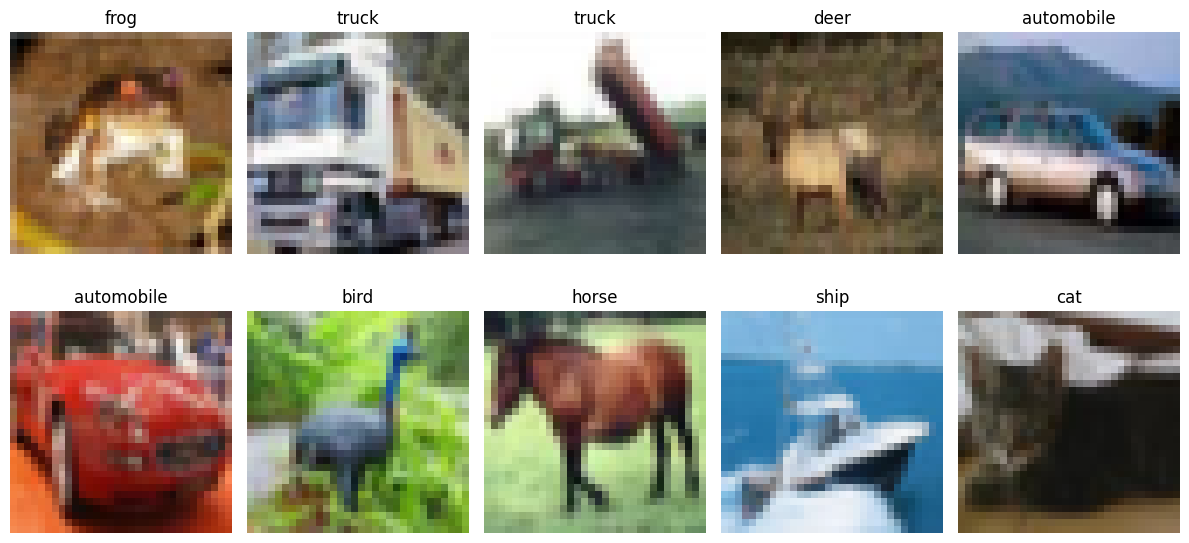

In [4]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Visualization

Visualizing sample images helps us:
- Understand image size and clarity
- Observe class diversity
- Verify that data is loaded correctly

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Pixel range after normalization:")
print("Min:", x_train.min())
print("Max:", x_train.max())

Pixel range after normalization:
Min: 0.0
Max: 1.0


## Data Normalization

Pixel values originally range from 0 to 255.
We scale them to the range [0,1] by dividing by 255.

This helps:
- Faster convergence during training
- Stable gradient updates
- Better model performance

In [6]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Label shape after one-hot encoding:", y_train.shape)

Label shape after one-hot encoding: (50000, 10)


## One-Hot Encoding

The model uses categorical_crossentropy loss,
which requires labels in one-hot encoded format.

Example:
Class 3 becomes:
[0,0,0,1,0,0,0,0,0,0]

## CNN Architecture

We design a Convolutional Neural Network with multiple convolutional 
blocks followed by fully connected layers.

The architecture includes:
- Conv2D layers with ReLU activation
- MaxPooling layers for downsampling
- Dropout for regularization
- Dense layers for classification
- Softmax output for 10 classes

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [8]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10, activation='softmax'))

c:\Users\ashifa\Desktop\gpp\CNN-CIFAR10\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Architectural Justification

- 3 convolutional blocks allow progressive feature extraction.
- Increasing filters (32 → 64 → 128) enables learning more complex patterns.
- 3x3 kernel size is standard for capturing local spatial features.
- MaxPooling reduces spatial dimensions and prevents overfitting.
- Dropout (0.5) reduces overfitting by randomly disabling neurons.
- Softmax output provides probability distribution over 10 classes.

## Model Compilation

We compile the model using:
- Adam optimizer for adaptive learning
- Categorical Crossentropy loss for multi-class classification
- Accuracy as evaluation metric

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Data Augmentation

Data augmentation artificially increases the diversity of training data 
by applying random transformations such as:

- Horizontal flipping
- Rotation
- Width and height shifts

This helps reduce overfitting and improves generalization.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

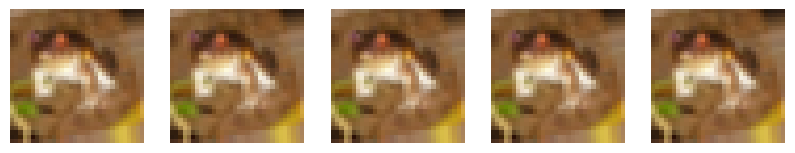

In [13]:
plt.figure(figsize=(10,6))

for X_batch, y_batch in datagen.flow(x_train[:1], y_train[:1], batch_size=1):
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(X_batch[0])
        plt.axis('off')
    break

plt.show()

## Learning Rate Scheduling and Model Checkpointing

To improve training stability and performance, we use:

- ReduceLROnPlateau: Reduces learning rate when validation loss stops improving.
- ModelCheckpoint: Saves the best model weights during training.

In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

In [15]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [16]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

## Model Training

The model is trained using augmented training data for 50 epochs.
We include learning rate scheduling and model checkpointing 
to improve performance and save the best model.

In [17]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler, checkpoint]
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.2488 - loss: 1.9979
Epoch 1: val_accuracy improved from None to 0.49110, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 207s 228ms/step - accuracy: 0.3226 - loss: 1.8199 - val_accuracy: 0.4911 - val_loss: 1.4196 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4515 - loss: 1.5114
Epoch 2: val_accuracy improved from 0.49110 to 0.56130, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 133s 170ms/step - accuracy: 0.4689 - loss: 1.4661 - val_accuracy: 0.5613 - val_loss: 1.2215 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5169 - loss: 1.3450
Epoch 3: val_accuracy improved from 0.56130 to 0.61260, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 132ms/step - accuracy: 0.5305 - loss: 1.3118 - val_accuracy: 0.6126 - val_loss: 1.0724 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5582 - loss: 1.2401
Epoch 4: val_accuracy improved from 0.61260 to 0.65090, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 142ms/step - accuracy: 0.5672 - loss: 1.2193 - val_accuracy: 0.6509 - val_loss: 0.9836 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5922 - loss: 1.1631
Epoch 5: val_accuracy improved from 0.65090 to 0.66250, saving model to best_model.h5


...

782/782 ━━━━━━━━━━━━━━━━━━━━ 126s 161ms/step - accuracy: 0.7861 - loss: 0.6293 - val_accuracy: 0.7988 - val_loss: 0.5973 - learning_rate: 2.5000e-04
Epoch 34/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.7886 - loss: 0.6162
Epoch 34: val_accuracy did not improve from 0.79880
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 182ms/step - accuracy: 0.7882 - loss: 0.6199 - val_accuracy: 0.7935 - val_loss: 0.6169 - learning_rate: 2.5000e-04
Epoch 35/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7907 - loss: 0.6153
Epoch 35: val_accuracy did not improve from 0.79880
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 172ms/step - accuracy: 0.7901 - loss: 0.6168 - val_accuracy: 0.7976 - val_loss: 0.6203 - learning_rate: 2.5000e-04
Epoch 36/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7901 - loss: 0.6164
Epoch 36: val_accuracy improved from 0.79880 to 0.80220, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 153s 185ms/step - accuracy: 0.7893 - loss: 0.6180 - val_accuracy: 0.8022 - val_loss: 0.5920 - learning_rate: 2.5000e-04
Epoch 37/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7884 - loss: 0.6124
Epoch 37: val_accuracy did not improve from 0.80220
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 186ms/step - accuracy: 0.7900 - loss: 0.6113 - val_accuracy: 0.7974 - val_loss: 0.6271 - learning_rate: 2.5000e-04
Epoch 38/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7899 - loss: 0.6102
Epoch 38: val_accuracy improved from 0.80220 to 0.80460, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 150ms/step - accuracy: 0.7890 - loss: 0.6162 - val_accuracy: 0.8046 - val_loss: 0.5915 - learning_rate: 2.5000e-04
Epoch 39/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7926 - loss: 0.6104
Epoch 39: val_accuracy did not improve from 0.80460
782/782 ━━━━━━━━━━━━━━━━━━━━ 150s 160ms/step - accuracy: 0.7935 - loss: 0.6069 - val_accuracy: 0.7931 - val_loss: 0.6364 - learning_rate: 2.5000e-04
Epoch 40/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7946 - loss: 0.5974
Epoch 40: val_accuracy improved from 0.80460 to 0.80760, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 157ms/step - accuracy: 0.7919 - loss: 0.6056 - val_accuracy: 0.8076 - val_loss: 0.5866 - learning_rate: 2.5000e-04
Epoch 41/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7922 - loss: 0.5973
Epoch 41: val_accuracy did not improve from 0.80760
782/782 ━━━━━━━━━━━━━━━━━━━━ 131s 167ms/step - accuracy: 0.7949 - loss: 0.5978 - val_accuracy: 0.7949 - val_loss: 0.6190 - learning_rate: 2.5000e-04
Epoch 42/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7934 - loss: 0.6098
Epoch 42: val_accuracy improved from 0.80760 to 0.81300, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 149ms/step - accuracy: 0.7946 - loss: 0.6024 - val_accuracy: 0.8130 - val_loss: 0.5629 - learning_rate: 2.5000e-04
Epoch 43/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7975 - loss: 0.5978
Epoch 43: val_accuracy did not improve from 0.81300
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 146ms/step - accuracy: 0.7967 - loss: 0.5975 - val_accuracy: 0.8033 - val_loss: 0.6030 - learning_rate: 2.5000e-04
Epoch 44/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7982 - loss: 0.5968
Epoch 44: val_accuracy did not improve from 0.81300
782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 153ms/step - accuracy: 0.7961 - loss: 0.6002 - val_accuracy: 0.8076 - val_loss: 0.5996 - learning_rate: 2.5000e-04
Epoch 45/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7986 - loss: 0.5937
Epoch 45: val_accuracy did not improve from 0.81300
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 159ms/step - accuracy: 0.7995 - loss: 0.5886 - val_accuracy: 0.8061 - val_loss: 0.5786 - learnin

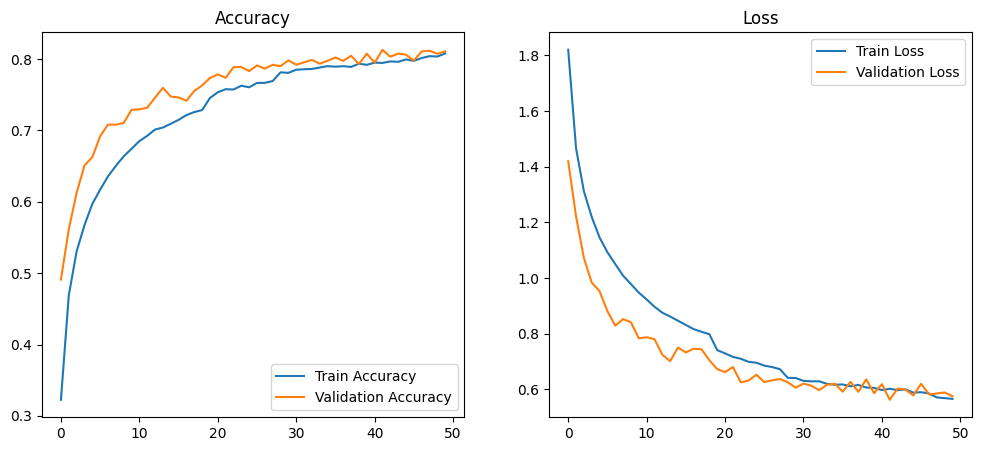

In [28]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.savefig("outputs/accuracy_loss_plot.png", dpi=300)

plt.show()

In [19]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5')

In [20]:
test_loss, test_accuracy = best_model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8130 - loss: 0.5629
Test Accuracy: 0.8130000233650208


In [21]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1000
           1       0.89      0.92      0.90      1000
           2       0.81      0.67      0.73      1000
           3       0.70      0.64      0.67      1000
           4       0.83      0.75      0.79      1000
           5       0.76      0.73      0.74      1000
           6       0.77      0.91      0.84      1000
           7       0.82      0.87      0.84      1000
           8       0.92      0.89      0.90      1000
           9       0.80      0.92      0.86      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



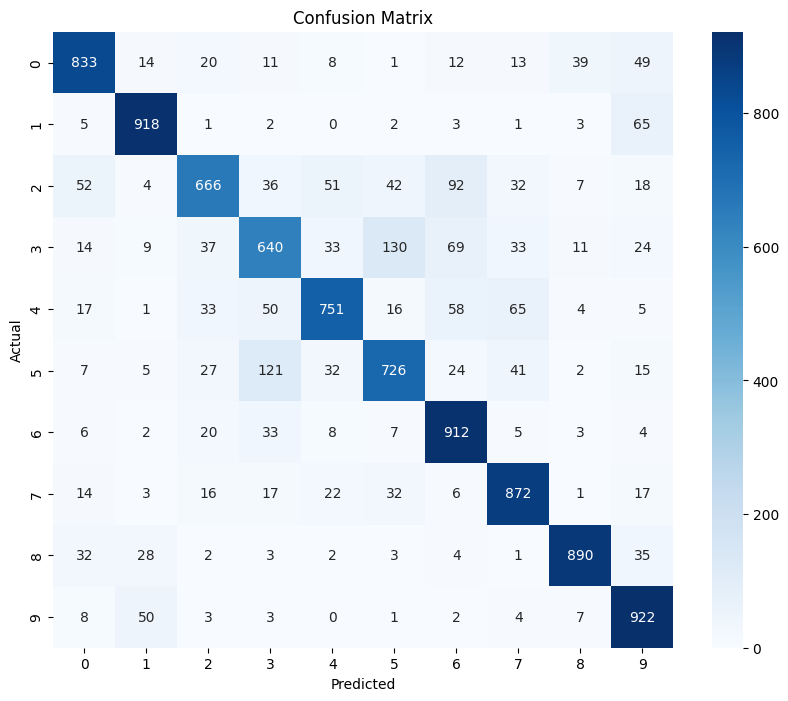

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("outputs/confusion_matrix.png", dpi=300)
plt.show()

In [23]:
misclassified = np.where(y_pred_classes != y_true)[0]

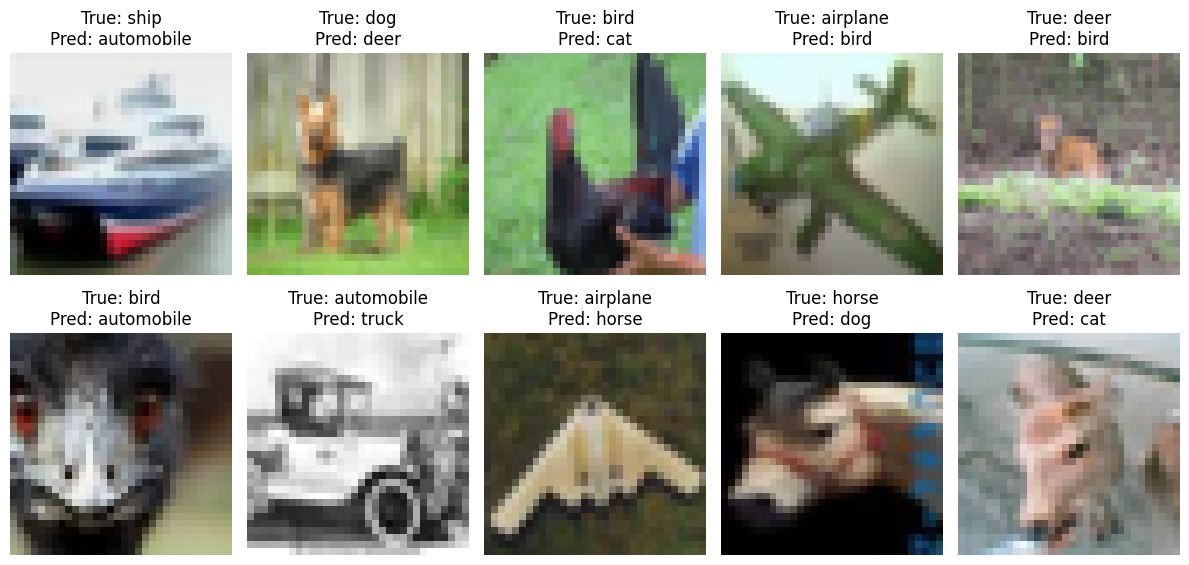

In [ ]:
plt.figure(figsize=(12,6))

for i, index in enumerate(misclassified[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[index])
    plt.title(f"True: {class_names[y_true[index]]}\nPred: {class_names[y_pred_classes[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
from tensorflow.keras.models import Model

_ = best_model.predict(x_test[:1])
layer_model = Model(
    inputs=best_model.inputs,
    outputs=best_model.layers[0].output
)

feature_maps = layer_model.predict(x_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


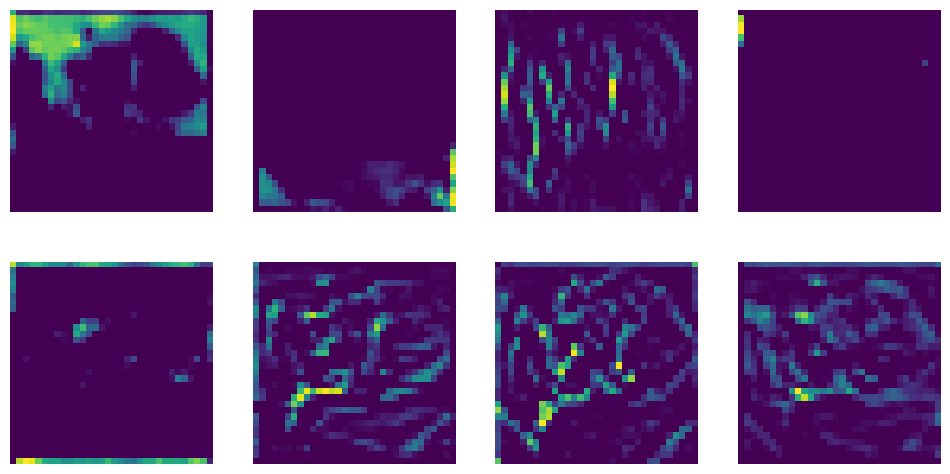

In [31]:
plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.savefig("outputs/feature_maps.png", dpi=300)
plt.show()

## Feature Map Analysis

The feature maps from the first convolutional layer show that the model
learns low-level features such as edges, color transitions, and textures.

Some filters activate strongly in regions with high contrast or distinct
patterns, while others remain inactive for the selected image.

This demonstrates that the CNN is effectively extracting spatial features
before passing them to deeper layers for higher-level abstraction.